<a href="https://colab.research.google.com/github/SemalDeSilva/TEAI/blob/IT22224248-Plucking-Quality-Grading/TeaaF1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import tensorflow as tf

# Mount Drive so you can read images and save models permanently
drive.mount('/content/drive')

# Verify GPU is working
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Check Runtime settings.')
else:
  print('Found GPU at: {}'.format(device_name))

Mounted at /content/drive
Found GPU at: /device:GPU:0


In [9]:
import cv2
import os
import glob

BASE_PATH = "/content/drive/MyDrive/Tea/Teaa"
AUG_TAGS = ["_fliph", "_flipv", "_rot90", "_rot180"]

def augment_and_save(img_path):
    img = cv2.imread(img_path)
    if img is None: return

    # Split the file name and extension
    base_name, ext = os.path.splitext(os.path.basename(img_path))
    dir_name = os.path.dirname(img_path)

    # 1. Horizontal Flip
    cv2.imwrite(os.path.join(dir_name, f"{base_name}_fliph{ext}"), cv2.flip(img, 1))

    # 2. Vertical Flip
    cv2.imwrite(os.path.join(dir_name, f"{base_name}_flipv{ext}"), cv2.flip(img, 0))

    # 3. Rotate 90
    cv2.imwrite(os.path.join(dir_name, f"{base_name}_rot90{ext}"), cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))

    # 4. Rotate 180
    cv2.imwrite(os.path.join(dir_name, f"{base_name}_rot180{ext}"), cv2.rotate(img, cv2.ROTATE_180))

for category in ["Best", "Below Best", "Poor"]:
    folder_path = os.path.join(BASE_PATH, category)
    print(f"Scanning {category} for original images...")

    # Grab all images (jpg, jpeg, png)
    all_images = glob.glob(os.path.join(folder_path, "*.*"))
    original_images = []

    # Filter out files that already have our augmentation tags
    for f in all_images:
        if not any(tag in f for tag in AUG_TAGS):
            original_images.append(f)

    print(f"Found {len(original_images)} original images to augment in {category}.")

    for img_path in original_images:
        augment_and_save(img_path)

print("\nOffline Augmentation Complete! Your dataset has been multiplied by 5.")

Scanning Best for original images...
Found 357 original images to augment in Best.
Scanning Below Best for original images...
Found 179 original images to augment in Below Best.
Scanning Poor for original images...
Found 311 original images to augment in Poor.

Offline Augmentation Complete! Your dataset has been multiplied by 5.


In [10]:
import cv2
import numpy as np
import os
from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm # For a progress bar

# Define your paths
BASE_PATH = "/content/drive/MyDrive/Tea/Teaa"
SAVE_DIR = "/content/drive/MyDrive/Tea/TEAI_Data" # We will save arrays here
os.makedirs(SAVE_DIR, exist_ok=True)

# For Stage 1: Best & Below Best = Acceptable (0), Poor = Poor (1)
CLASSES = {"Best": 0, "Below Best": 0, "Poor": 1}

X_images = []
X_features = []
Y_labels = []

# Extraction Logic
def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None: return None, None
    img = cv2.resize(img, (224, 224))

    # Masking (Yellow-Green to Dark Green)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([25, 40, 40]), np.array([90, 255, 255]))
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # HSV Stats
    masked_hsv = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
    valid = mask > 0
    mean_v = np.mean(masked_hsv[:,:,2][valid]) if np.any(valid) else 0
    mean_h = np.mean(masked_hsv[:,:,0][valid]) if np.any(valid) else 0

    # GLCM Texture (Contrast & Homogeneity)
    gray = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = np.mean(graycoprops(glcm, 'contrast'))
    homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))

    return masked_img, np.array([mean_v, mean_h, contrast, homogeneity])

# Process the folders
for folder_name, label in CLASSES.items():
    folder_path = os.path.join(BASE_PATH, folder_name)

    if not os.path.exists(folder_path):
        print(f"Warning: Folder not found at {folder_path}. Skipping...")
        continue

    print(f"Processing {folder_name}...")

    for filename in tqdm(os.listdir(folder_path)):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            img_array, feat_array = extract_features(img_path)

            if img_array is not None:
                X_images.append(img_array)
                X_features.append(feat_array)
                Y_labels.append(label)

# Only save if we found data
if len(X_images) > 0:
    np.save(os.path.join(SAVE_DIR, 'X_images_stage1.npy'), np.array(X_images))
    np.save(os.path.join(SAVE_DIR, 'X_features_stage1.npy'), np.array(X_features))
    np.save(os.path.join(SAVE_DIR, 'Y_labels_stage1.npy'), np.array(Y_labels))
    print(f"Extraction Complete! Processed {len(X_images)} images and Saved to Drive!")
else:
    print("No images were found. Please check your folder paths.")

Processing Best...


100%|██████████| 1785/1785 [01:25<00:00, 20.99it/s]


Processing Below Best...


100%|██████████| 895/895 [01:00<00:00, 14.71it/s]


Processing Poor...


100%|██████████| 1555/1555 [01:30<00:00, 17.19it/s]


Extraction Complete! Processed 4235 images and Saved to Drive!


In [11]:
import numpy as np
from sklearn.model_selection import train_test_split

SAVE_DIR = "/content/drive/MyDrive/Tea/TEAI_Data"

print("Loading data from Drive...")
X_imgs = np.load(os.path.join(SAVE_DIR, 'X_images_stage1.npy'))
X_feats = np.load(os.path.join(SAVE_DIR, 'X_features_stage1.npy'))
Y_lbls = np.load(os.path.join(SAVE_DIR, 'Y_labels_stage1.npy'))

# Split into Training and Validation sets (85% Train, 15% Validation)
X_img_train, X_img_val, X_feat_train, X_feat_val, y_train, y_val = train_test_split(
    X_imgs, X_feats, Y_lbls, test_size=0.15, random_state=42, stratify=Y_lbls
)

print(f"Training samples: {len(y_train)}")
print(f"Validation samples: {len(y_val)}")

Loading data from Drive...
Training samples: 3599
Validation samples: 636


In [12]:
from tensorflow.keras import layers, models, regularizers

def build_stage1_hybrid():
    # Branch 1: CNN for images
    img_in = layers.Input(shape=(224, 224, 3), name="img_in")
    x = layers.Rescaling(1./255)(img_in)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    cnn_out = layers.GlobalAveragePooling2D()(x) # Drastically reduces params

    # Branch 2: Dense for explicit features (HSV & GLCM)
    feat_in = layers.Input(shape=(4,), name="feat_in")
    y = layers.Dense(16, activation="relu")(feat_in)
    y = layers.BatchNormalization()(y)
    feat_out = layers.Dense(16, activation="relu")(y)

    # Merge
    combined = layers.Concatenate()([cnn_out, feat_out])
    z = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(combined)
    z = layers.Dropout(0.4)(z)

    # Output: 1 neuron (Sigmoid) because it is binary (Acceptable vs Poor)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(z)

    return models.Model(inputs=[img_in, feat_in], outputs=outputs)

stage1_model = build_stage1_hybrid()
stage1_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
                     loss="binary_crossentropy",
                     metrics=["accuracy"])
stage1_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_in (InputLayer) │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ img_in[0][0]      │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_in             │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         80 │ feat_in[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16)        │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        272 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,433 (87.63 KB)

 Trainable params: 22,401 (87.50 KB)

 Non-trainable params: 32 (128.00 B)

Starting final Stage 1 training...
Epoch 1/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8116 - loss: 0.4293 - val_accuracy: 0.8176 - val_loss: 0.3997 - learning_rate: 5.0000e-04
Epoch 2/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8041 - loss: 0.4330 - val_accuracy: 0.8145 - val_loss: 0.4030 - learning_rate: 5.0000e-04
Epoch 3/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8047 - loss: 0.4326 - val_accuracy: 0.8113 - val_loss: 0.4052 - learning_rate: 5.0000e-04
Epoch 4/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8097 - loss: 0.4322 - val_accuracy: 0.8160 - val_loss: 0.3774 - learning_rate: 5.0000e-04
Epoch 5/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8111 - loss: 0.4258 - val_accuracy: 0.8318 - val_loss: 0.3669 - learning_rate: 5.0000e-04
Epoch 6/80
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8099 - loss: 0.4283 - val_accuracy: 0.8286 - val_loss: 0.3722 - learning_rate: 5.0000e-04
Epoch 7/80
225/225 ━━━━

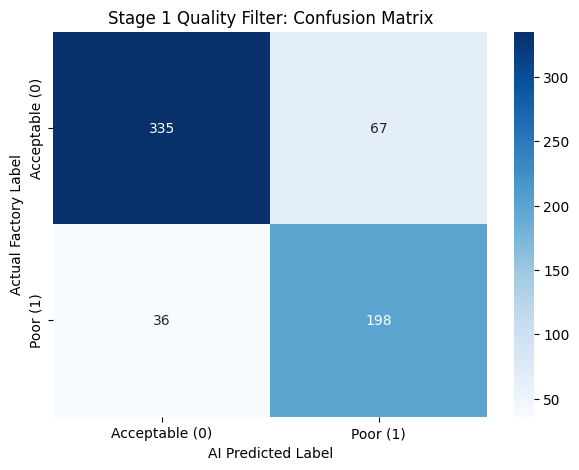


--- Classification Report ---
              precision    recall  f1-score   support

  Acceptable       0.90      0.83      0.87       402
        Poor       0.75      0.85      0.79       234

    accuracy                           0.84       636
   macro avg       0.83      0.84      0.83       636
weighted avg       0.85      0.84      0.84       636



In [14]:
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Ensure this matches your actual Drive path
MODEL_SAVE_PATH = "/content/drive/MyDrive/Tea/TEAI_Data/stage1_best_model.keras"

# 1. Define the upgraded callbacks
callbacks = [
    # Halts training if no improvement for 10 epochs
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    # Saves the highest validation accuracy
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor="val_accuracy"),
    # Reduces learning rate automatically when progress stalls
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

# 2. Calculate class weights to handle dataset imbalances
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

print("Starting final Stage 1 training...")

# 3. Train the model (Epochs increased to 80)
history = stage1_model.fit(
    x={"img_in": X_img_train, "feat_in": X_feat_train},
    y=y_train,
    validation_data=({"img_in": X_img_val, "feat_in": X_feat_val}, y_val),
    epochs=80,
    batch_size=16,
    callbacks=callbacks,
    class_weight=class_weights
)

print(f"\nTraining finished! Best model saved to {MODEL_SAVE_PATH}")
print("Generating Confusion Matrix for the best epoch...\n")

# 4. Load the absolute best weights saved by the Checkpoint
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)

# 5. Predict on validation data
y_pred_probs = best_model.predict({"img_in": X_img_val, "feat_in": X_feat_val})
y_pred = (y_pred_probs > 0.5).astype(int)

# 6. Generate visualizations
# 0 = Acceptable (Best/Below Best), 1 = Poor
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Acceptable (0)', 'Poor (1)'],
            yticklabels=['Acceptable (0)', 'Poor (1)'])
plt.ylabel('Actual Factory Label')
plt.xlabel('AI Predicted Label')
plt.title('Stage 1 Quality Filter: Confusion Matrix')
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_val, y_pred, target_names=['Acceptable', 'Poor']))

In [16]:
import cv2
import numpy as np
import os
from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm

BASE_PATH = "/content/drive/MyDrive/Tea/Teaa"
SAVE_DIR = "/content/drive/MyDrive/Tea/TEAI_Data"

# ONLY process these two. Best = 1, Below Best = 0
STAGE2_CLASSES = {"Best": 1, "Below Best": 0}

X_img_s2 = []
X_feat_s2 = []
Y_lbl_s2 = []

def extract_stage2_features(img_path):
    img = cv2.imread(img_path)
    if img is None: return None, None
    img = cv2.resize(img, (224, 224))

    # Masking
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([25, 40, 40]), np.array([90, 255, 255]))
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # HSV Stats
    masked_hsv = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
    valid = mask > 0
    mean_v = np.mean(masked_hsv[:,:,2][valid]) if np.any(valid) else 0
    mean_h = np.mean(masked_hsv[:,:,0][valid]) if np.any(valid) else 0

    # GLCM Texture (Crucial for Stage 2)
    gray = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = np.mean(graycoprops(glcm, 'contrast'))
    homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))

    return masked_img, np.array([mean_v, mean_h, contrast, homogeneity])

for folder_name, label in STAGE2_CLASSES.items():
    folder_path = os.path.join(BASE_PATH, folder_name)
    print(f"Processing {folder_name} for Stage 2...")

    for filename in tqdm(os.listdir(folder_path)):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            img_array, feat_array = extract_stage2_features(img_path)

            if img_array is not None:
                X_img_s2.append(img_array)
                X_feat_s2.append(feat_array)
                Y_lbl_s2.append(label)

np.save(os.path.join(SAVE_DIR, 'X_images_stage2.npy'), np.array(X_img_s2))
np.save(os.path.join(SAVE_DIR, 'X_features_stage2.npy'), np.array(X_feat_s2))
np.save(os.path.join(SAVE_DIR, 'Y_labels_stage2.npy'), np.array(Y_lbl_s2))
print("\nStage 2 Extraction Complete and Saved!")

Processing Best for Stage 2...


100%|██████████| 1785/1785 [01:22<00:00, 21.65it/s]


Processing Below Best for Stage 2...


100%|██████████| 895/895 [01:00<00:00, 14.78it/s]



Stage 2 Extraction Complete and Saved!


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Load the new Stage 2 Data
X_imgs = np.load(os.path.join(SAVE_DIR, 'X_images_stage2.npy'))
X_feats = np.load(os.path.join(SAVE_DIR, 'X_features_stage2.npy'))
Y_lbls = np.load(os.path.join(SAVE_DIR, 'Y_labels_stage2.npy'))

X_img_tr, X_img_val, X_feat_tr, X_feat_val, y_tr, y_val = train_test_split(
    X_imgs, X_feats, Y_lbls, test_size=0.15, random_state=42, stratify=Y_lbls
)

# Build a fresh copy of the model
stage2_model = build_stage1_hybrid() # Reusing the architecture function
stage2_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
                     loss="binary_crossentropy", metrics=["accuracy"])

STAGE2_MODEL_PATH = "/content/drive/MyDrive/Tea/TEAI_Data/stage2_best_model.keras"

callbacks_s2 = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ModelCheckpoint(STAGE2_MODEL_PATH, save_best_only=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

weights_s2 = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights_s2 = dict(enumerate(weights_s2))

print("Starting Stage 2 Refiner training...")
history_s2 = stage2_model.fit(
    x={"img_in": X_img_tr, "feat_in": X_feat_tr}, y=y_tr,
    validation_data=({"img_in": X_img_val, "feat_in": X_feat_val}, y_val),
    epochs=80, batch_size=16, callbacks=callbacks_s2, class_weight=class_weights_s2
)

Starting Stage 2 Refiner training...
Epoch 1/80
143/143 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.6014 - loss: 0.6841 - val_accuracy: 0.3881 - val_loss: 0.7038 - learning_rate: 5.0000e-04
Epoch 2/80
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6949 - loss: 0.6219 - val_accuracy: 0.5622 - val_loss: 0.6511 - learning_rate: 5.0000e-04
Epoch 3/80
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7147 - loss: 0.5581 - val_accuracy: 0.5945 - val_loss: 0.6000 - learning_rate: 5.0000e-04
Epoch 4/80
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7379 - loss: 0.5337 - val_accuracy: 0.7736 - val_loss: 0.4820 - learning_rate: 5.0000e-04
Epoch 5/80
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7502 - loss: 0.5149 - val_accuracy: 0.7761 - val_loss: 0.4763 - learning_rate: 5.0000e-04
Epoch 6/80
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7498 - loss: 0.5095 - val_accuracy: 0.7886 - val_loss: 0.4635 - learning_rate: 5.0000e-04
Epoch 7/80
143/143 ━

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step


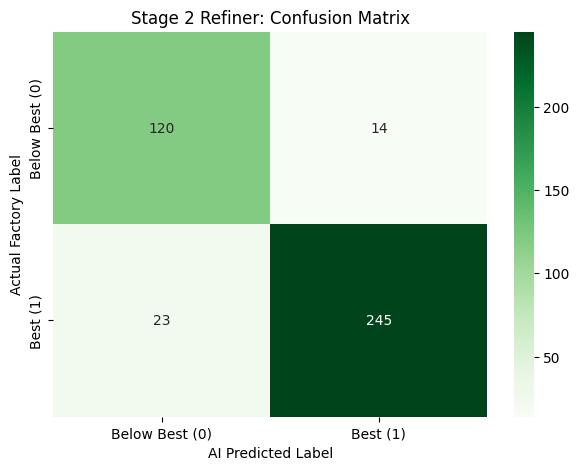


--- Stage 2 Classification Report ---
              precision    recall  f1-score   support

  Below Best       0.84      0.90      0.87       134
        Best       0.95      0.91      0.93       268

    accuracy                           0.91       402
   macro avg       0.89      0.90      0.90       402
weighted avg       0.91      0.91      0.91       402



In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# Load the absolute best weights saved by the Stage 2 Checkpoint
best_stage2_model = tf.keras.models.load_model(STAGE2_MODEL_PATH)

# Predict on Stage 2 validation data
y_pred_probs_s2 = best_stage2_model.predict({"img_in": X_img_val, "feat_in": X_feat_val})
y_pred_s2 = (y_pred_probs_s2 > 0.5).astype(int)

# Generate visualizations
# 0 = Below Best, 1 = Best
cm_s2 = confusion_matrix(y_val, y_pred_s2)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Below Best (0)', 'Best (1)'],
            yticklabels=['Below Best (0)', 'Best (1)'])
plt.ylabel('Actual Factory Label')
plt.xlabel('AI Predicted Label')
plt.title('Stage 2 Refiner: Confusion Matrix')
plt.show()

print("\n--- Stage 2 Classification Report ---")
print(classification_report(y_val, y_pred_s2, target_names=['Below Best', 'Best']))

Loading TEAI Cascade Models from Drive...
Models loaded successfully!

Upload a Tea Leaf Image to test the TEAI Pipeline:


Saving sample_008_20251223_192633_raw.jpg to sample_008_20251223_192633_raw.jpg

--- Processing: sample_008_20251223_192633_raw.jpg ---
Extracted Features -> HSV Val: 65.6, Contrast: 138.6, Homogeneity: 0.8


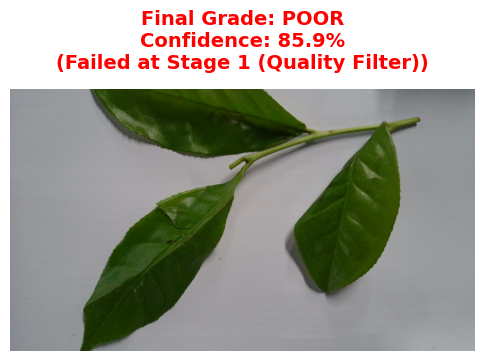

In [22]:
import cv2
import numpy as np
import tensorflow as tf
from skimage.feature import graycomatrix, graycoprops
from google.colab import files
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD THE TRAINED MODELS
# ==========================================
print("Loading TEAI Cascade Models from Drive...")
STAGE1_PATH = "/content/drive/MyDrive/Tea/TEAI_Data/stage1_best_model.keras"
STAGE2_PATH = "/content/drive/MyDrive/Tea/TEAI_Data/stage2_best_model.keras"

try:
    stage1_model = tf.keras.models.load_model(STAGE1_PATH)
    stage2_model = tf.keras.models.load_model(STAGE2_PATH)
    print("Models loaded successfully!\n")
except Exception as e:
    print(f"Error loading models. Check your Drive paths: {e}")

# ==========================================
# 2. FEATURE EXTRACTION (Single Image)
# ==========================================
def process_single_image(image_bytes):
    # Convert uploaded bytes to OpenCV image
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    original_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Save for displaying later

    # Resize and Mask
    img_resized = cv2.resize(img, (224, 224))
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([25, 40, 40]), np.array([90, 255, 255]))
    masked_img = cv2.bitwise_and(img_resized, img_resized, mask=mask)

    # Extract HSV Scores
    masked_hsv = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
    valid = mask > 0
    mean_v = np.mean(masked_hsv[:,:,2][valid]) if np.any(valid) else 0
    mean_h = np.mean(masked_hsv[:,:,0][valid]) if np.any(valid) else 0

    # Extract GLCM Texture Scores
    gray = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = np.mean(graycoprops(glcm, 'contrast'))
    homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))

    features = np.array([mean_v, mean_h, contrast, homogeneity])

    # Reshape for Keras (Batch Size of 1)
    img_input = np.expand_dims(masked_img, axis=0)
    feat_input = np.expand_dims(features, axis=0)

    return original_img, img_input, feat_input, features

# ==========================================
# 3. UPLOAD & INFERENCE PIPELINE
# ==========================================
print("Upload a Tea Leaf Image to test the TEAI Pipeline:")
uploaded = files.upload()

for filename, data in uploaded.items():
    print(f"\n--- Processing: {filename} ---")

    # 1. Extract Features
    orig_img, img_in, feat_in, raw_features = process_single_image(data)

    print(f"Extracted Features -> HSV Val: {raw_features[0]:.1f}, Contrast: {raw_features[2]:.1f}, Homogeneity: {raw_features[3]:.1f}")

    # 2. RUN STAGE 1 (Quality Filter)
    # Stage 1: 0 = Acceptable, 1 = Poor
    s1_prob = stage1_model.predict({"img_in": img_in, "feat_in": feat_in}, verbose=0)[0][0]

    if s1_prob > 0.5:
        final_grade = "POOR"
        confidence = s1_prob * 100
        stage_info = "Failed at Stage 1 (Quality Filter)"
    else:
        print("Leaf is Acceptable. Passing to Stage 2 Refiner...")

        # 3. RUN STAGE 2 (Refiner)
        # Stage 2: 0 = Below Best, 1 = Best
        s2_prob = stage2_model.predict({"img_in": img_in, "feat_in": feat_in}, verbose=0)[0][0]

        if s2_prob > 0.5:
            final_grade = "BEST"
            confidence = s2_prob * 100
            stage_info = "Passed Stage 1 -> Graded at Stage 2"
        else:
            final_grade = "BELOW BEST"
            confidence = (1 - s2_prob) * 100
            stage_info = "Passed Stage 1 -> Graded at Stage 2"

    # ==========================================
    # 4. DISPLAY RESULTS
    # ==========================================
    plt.figure(figsize=(6, 6))
    plt.imshow(orig_img)
    plt.axis('off')

    # Color-code the output text
    color_map = {"BEST": "green", "BELOW BEST": "orange", "POOR": "red"}
    text_color = color_map.get(final_grade, "black")

    plt.title(f"Final Grade: {final_grade}\nConfidence: {confidence:.1f}%\n({stage_info})",
              fontsize=14, color=text_color, fontweight='bold', pad=15)
    plt.show()